PART-**A**

In [1]:
# CNN Image Classification

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
print("RITHANYA.G 24BAD132")
print("TensorFlow Version:", tf.__version__)

RITHANYA.G 24BAD132
TensorFlow Version: 2.20.0


In [2]:
# Load CIFAR-10 dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1296s 8us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


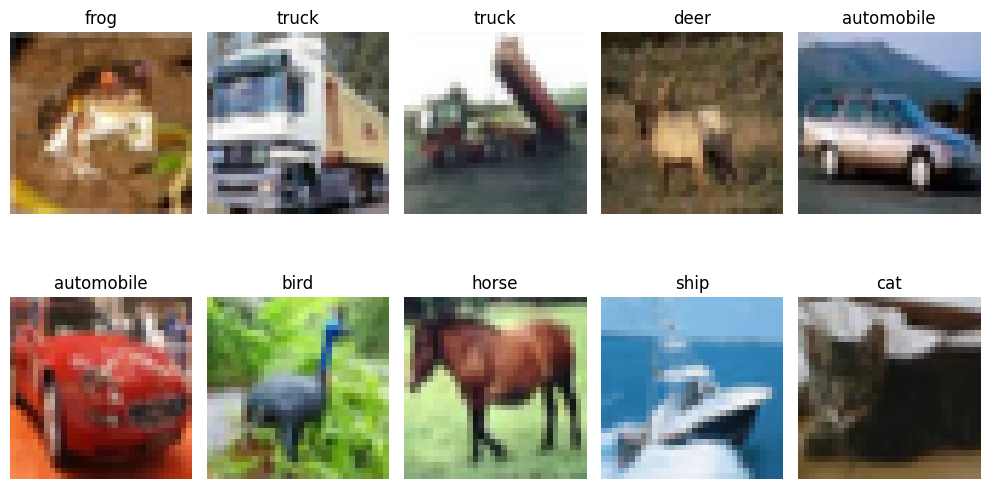

In [3]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Normalize pixel values

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
# Create validation dataset

x_val = x_train[45000:]
y_val = y_train[45000:]

x_train = x_train[:45000]
y_train = y_train[:45000]

print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)

Training data: (45000, 32, 32, 3)
Validation data: (5000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


PART-**B**

In [6]:
# Build CNN model

model = models.Sequential([

    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu'),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile CNN model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [10]:
# Train the CNN

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.9254 - loss: 0.2147 - val_accuracy: 0.7144 - val_loss: 1.2641
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9300 - loss: 0.1950 - val_accuracy: 0.7262 - val_loss: 1.2967
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.9411 - loss: 0.1694 - val_accuracy: 0.7148 - val_loss: 1.4653
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.9459 - loss: 0.1520 - val_accuracy: 0.7112 - val_loss: 1.4315
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.9526 - loss: 0.1369 - val_accuracy: 0.7118 - val_loss: 1.5771
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.9559 - loss: 0.1256 - val_accuracy: 0.7080 - val_loss: 1.6313
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 52ms/step - accuracy: 0.9573 - loss: 0.1191 - val_accuracy: 0.7092 - val_loss: 1.7310
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9602 - loss: 0.1121 - 

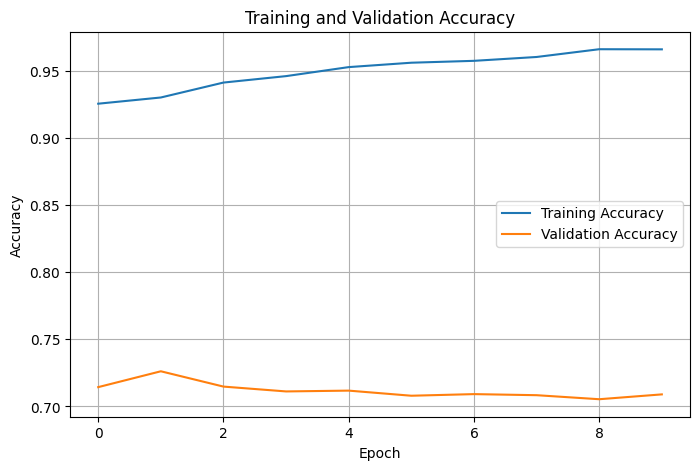

In [11]:
# Plot Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

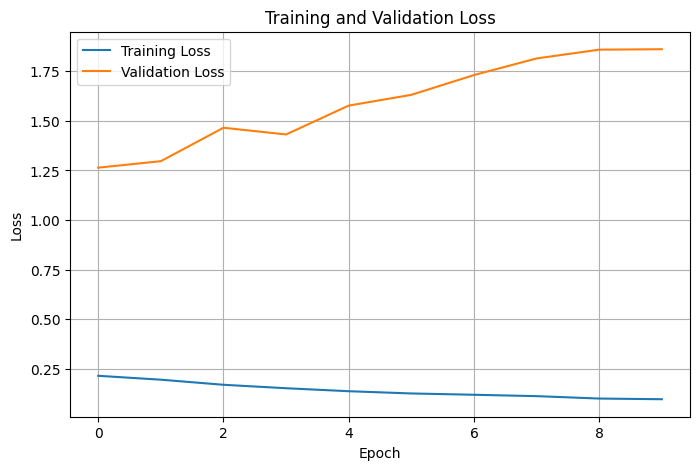

In [12]:
# Plot Loss

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

PART-**C**

In [13]:
# Evaluate model on test data

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6929 - loss: 1.9991
Test Loss: 1.9991189241409302
Test Accuracy: 0.6929000020027161
Test Accuracy (%): 69.2900002002716


PART-**D**

In [14]:
# Generate predictions

y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Predictions generated successfully.


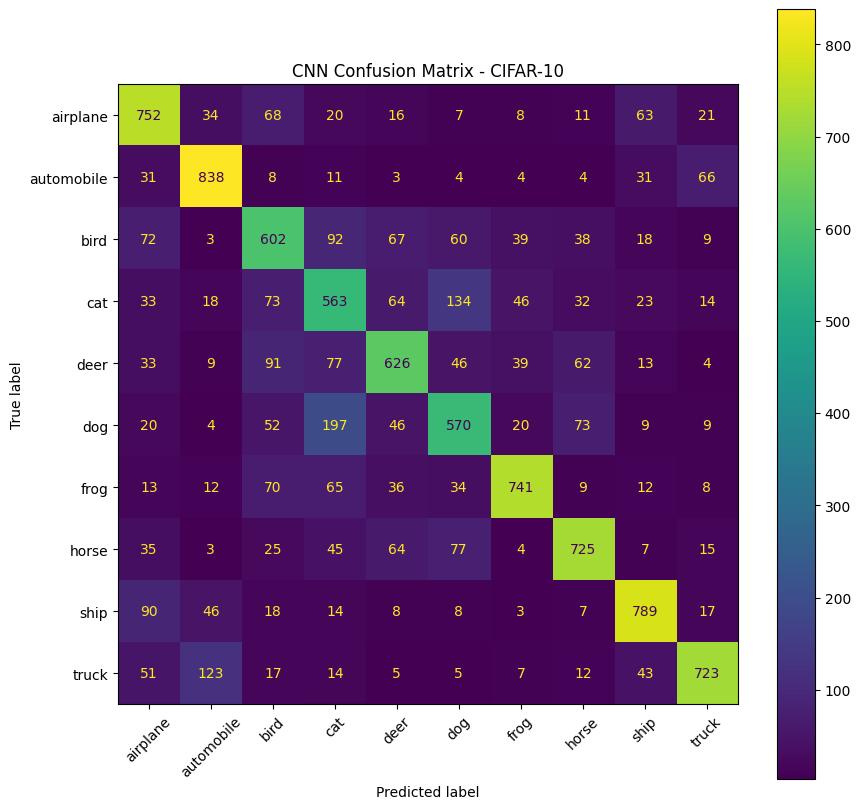

In [15]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("CNN Confusion Matrix - CIFAR-10")
plt.show()

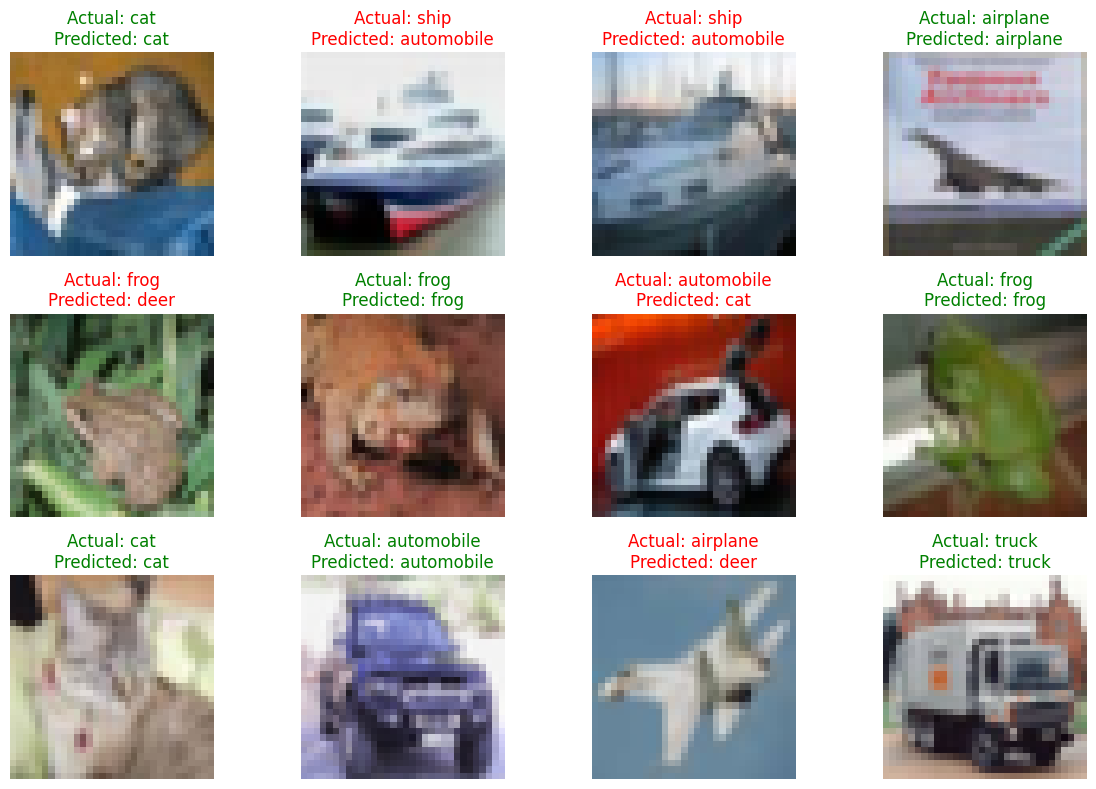

In [16]:
# Display sample predictions

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    predicted_label = class_names[y_pred_classes[i]]
    actual_label = class_names[y_true[i]]

    if predicted_label == actual_label:
        color = 'green'
    else:
        color = 'red'

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}",
        color=color
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
print("=" * 45)
print("       CNN IMAGE CLASSIFICATION RESULTS")
print("=" * 45)

print(f"Training Accuracy   : {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy       : {test_accuracy * 100:.2f}%")
print(f"Test Loss           : {test_loss:.4f}")

print("=" * 45)

       CNN IMAGE CLASSIFICATION RESULTS
Training Accuracy   : 96.59%
Validation Accuracy : 70.90%
Test Accuracy       : 69.29%
Test Loss           : 1.9991
